In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/crop_rain_state_2000_2024.csv")

df.head()

,year,period,geo_level,state,state_ansi,crop,data_item,domain,domain_category,yield_bu_per_acre,STATE_FIPS,state_abbr,annual_precip_in,growing_season_precip_in,non_growing_season_precip_in,growing_season_share,growing_season_precip_state_percentile,crop_damage_event_count,crop_damage_usd
0,2024,YEAR,STATE,ALABAMA,1.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,112.0,1.0,AL,56.407313,28.465224,27.942090,0.504637,60.0,0.0,0.0
1,2024,YEAR,STATE,ARIZONA,4.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,225.0,4.0,AZ,33.074138,3.027241,30.046897,0.091529,28.0,0.0,0.0
2,2024,YEAR,STATE,ARKANSAS,5.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,187.0,5.0,AR,20.227187,10.738906,9.488281,0.530914,52.0,1.0,1000.0
3,2024,YEAR,STATE,CALIFORNIA,6.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,182.0,6.0,CA,52.013750,25.927500,26.086250,0.498474,56.0,1.0,10.0
4,2024,YEAR,STATE,COLORADO,8.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,116.0,8.0,CO,57.152687,38.433582,18.719104,0.672472,68.0,18.0,29222000.0


In [2]:
df.columns

Index(['year', 'period', 'geo_level', 'state', 'state_ansi', 'crop',
       'data_item', 'domain', 'domain_category', 'yield_bu_per_acre',
       'STATE_FIPS', 'state_abbr', 'annual_precip_in',
       'growing_season_precip_in', 'non_growing_season_precip_in',
       'growing_season_share', 'growing_season_precip_state_percentile',
       'crop_damage_event_count', 'crop_damage_usd'],
      dtype='object')

In [3]:
df.shape

(5767, 19)

In [4]:
print(df['year'].min(), df['year'].max())
print(df['crop'].unique())
print(df['state'].nunique(), df['state'].unique())

2000 2024
['CORN' 'WHEAT' 'SOYBEANS']
43 ['ALABAMA' 'ARIZONA' 'ARKANSAS' 'CALIFORNIA' 'COLORADO' 'DELAWARE'
 'FLORIDA' 'GEORGIA' 'IDAHO' 'ILLINOIS' 'INDIANA' 'IOWA' 'KANSAS'
 'KENTUCKY' 'LOUISIANA' 'MARYLAND' 'MICHIGAN' 'MINNESOTA' 'MISSISSIPPI'
 'MISSOURI' 'MONTANA' 'NEBRASKA' 'NEW JERSEY' 'NEW MEXICO' 'NEW YORK'
 'NORTH CAROLINA' 'NORTH DAKOTA' 'OHIO' 'OKLAHOMA' 'OREGON' 'OTHER STATES'
 'PENNSYLVANIA' 'SOUTH CAROLINA' 'SOUTH DAKOTA' 'TENNESSEE' 'TEXAS' 'UTAH'
 'VIRGINIA' 'WASHINGTON' 'WEST VIRGINIA' 'WISCONSIN' 'WYOMING' 'NEVADA']


In [5]:
df.isna().sum().sort_values(ascending=False)

growing_season_share                      600
state_ansi                                 89
growing_season_precip_state_percentile     89
crop_damage_event_count                    89
crop_damage_usd                            89
state_abbr                                 89
STATE_FIPS                                 89
annual_precip_in                           89
growing_season_precip_in                   89
non_growing_season_precip_in               89
year                                        0
geo_level                                   0
period                                      0
yield_bu_per_acre                           0
domain_category                             0
state                                       0
crop                                        0
domain                                      0
data_item                                   0
dtype: int64

In [6]:
missing_89 = df[df["state_abbr"].isna()]
print(missing_89["state"].value_counts())
display(missing_89.head())

state
OTHER STATES    89
Name: count, dtype: int64


,year,period,geo_level,state,state_ansi,crop,data_item,domain,domain_category,yield_bu_per_acre,STATE_FIPS,state_abbr,annual_precip_in,growing_season_precip_in,non_growing_season_precip_in,growing_season_share,growing_season_precip_state_percentile,crop_damage_event_count,crop_damage_usd
30,2024,YEAR,STATE,OTHER STATES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,2023,YEAR,STATE,OTHER STATES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,2022,YEAR,STATE,OTHER STATES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,2021,YEAR,STATE,OTHER STATES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
198,2020,YEAR,STATE,OTHER STATES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Main EDA question

How do precipitation timing and damaging weather events vary across U.S. agricultural regions from 2000 to 2024, and how are these patterns related to crop damage and crop yield?

In [7]:
region_map = {
    # West Coast / Pacific
    "CALIFORNIA": "West Coast",
    "OREGON": "West Coast",
    "WASHINGTON": "West Coast",

    # Mountain / Interior West
    "ARIZONA": "Interior West",
    "COLORADO": "Interior West",
    "IDAHO": "Interior West",
    "MONTANA": "Interior West",
    "NEVADA": "Interior West",
    "NEW MEXICO": "Interior West",
    "UTAH": "Interior West",
    "WYOMING": "Interior West",

    # Midwest / Corn Belt / Plains
    "ILLINOIS": "Midwest / Plains",
    "INDIANA": "Midwest / Plains",
    "IOWA": "Midwest / Plains",
    "KANSAS": "Midwest / Plains",
    "MICHIGAN": "Midwest / Plains",
    "MINNESOTA": "Midwest / Plains",
    "MISSOURI": "Midwest / Plains",
    "NEBRASKA": "Midwest / Plains",
    "NORTH DAKOTA": "Midwest / Plains",
    "OHIO": "Midwest / Plains",
    "SOUTH DAKOTA": "Midwest / Plains",
    "WISCONSIN": "Midwest / Plains",

    # South
    "ALABAMA": "South",
    "ARKANSAS": "South",
    "FLORIDA": "South",
    "GEORGIA": "South",
    "KENTUCKY": "South",
    "LOUISIANA": "South",
    "MISSISSIPPI": "South",
    "NORTH CAROLINA": "South",
    "OKLAHOMA": "South",
    "SOUTH CAROLINA": "South",
    "TENNESSEE": "South",
    "TEXAS": "South",
    "VIRGINIA": "South",
    "WEST VIRGINIA": "South",

    # Northeast / Mid-Atlantic
    "DELAWARE": "Northeast",
    "MARYLAND": "Northeast",
    "NEW JERSEY": "Northeast",
    "NEW YORK": "Northeast",
    "PENNSYLVANIA": "Northeast",
}

We remove `OTHER STATES` because it is an aggregate USDA category rather than a real state. Keeping it would create missing state identifiers and make regional or map-based analysis misleading.

In [8]:
df_clean = df[df["state"] != "OTHER STATES"].copy()
df_clean["region"] = df_clean["state"].map(region_map)

print(df_clean.shape)
print(df_clean["state"].nunique())
print(df_clean["region"].value_counts(dropna=False))

(5678, 20)
42
region
South               2208
Midwest / Plains    2082
Northeast            869
Interior West        369
West Coast           150
Name: count, dtype: int64


In [9]:
state_year_cols = [
    "year",
    "state",
    "state_abbr",
    "region",
    "annual_precip_in",
    "growing_season_precip_in",
    "non_growing_season_precip_in",
    "growing_season_share",
    "growing_season_precip_state_percentile",
    "crop_damage_event_count",
    "crop_damage_usd"
]

state_year = df_clean[state_year_cols].drop_duplicates().copy()

print(state_year.shape)
print(state_year["state"].nunique())

(1044, 11)
42


In [10]:
crop_data = df_clean.copy()
damage_data = state_year.copy()
precip_data = state_year[state_year["annual_precip_in"] > 0].copy()

print("crop_data:", crop_data.shape)
print("damage_data:", damage_data.shape)
print("precip_data:", precip_data.shape)

print("crop states:", crop_data["state"].nunique())
print("damage states:", damage_data["state"].nunique())
print("precip states:", precip_data["state"].nunique())

crop_data: (5678, 20)
damage_data: (1044, 11)
precip_data: (919, 11)
crop states: 42
damage states: 42
precip states: 37


Because the merged dataset has different levels of analysis, we use different cleaned datasets for different questions. Crop yield is analyzed at the crop-state-year level. Crop damage and event counts are analyzed at the state-year level to avoid duplicated weather values across crops. Precipitation analysis uses only state-years with valid annual precipitation values.

Before analyzing regional patterns, we first check data availability by region. This figure is mainly a data-cleaning check rather than a main project finding.

,region,states_with_crop_damage_data,states_with_valid_precip_data
3,South,14,12
1,Midwest / Plains,12,11
0,Interior West,8,7
2,Northeast,5,5
4,West Coast,3,2


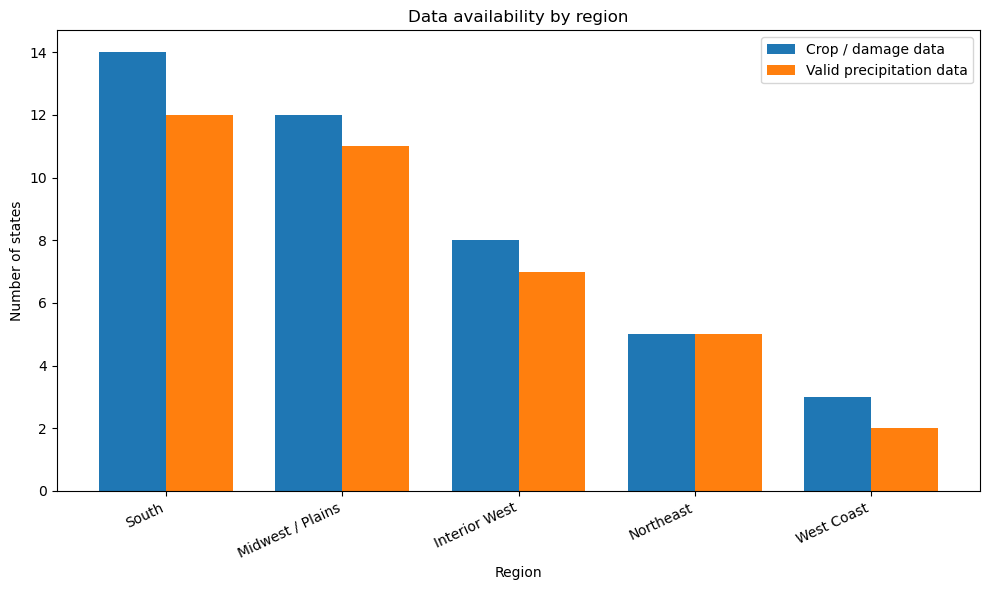

In [ ]:
# Count states with crop/damage data by region
crop_states_by_region = (
    damage_data[["state", "region"]]
    .drop_duplicates()
    .groupby("region")
    .size()
    .reset_index(name="states_with_crop_damage_data")
)

# Count states with valid precipitation data by region
precip_states_by_region = (
    precip_data[["state", "region"]]
    .drop_duplicates()
    .groupby("region")
    .size()
    .reset_index(name="states_with_valid_precip_data")
)

coverage = crop_states_by_region.merge(
    precip_states_by_region,
    on="region",
    how="left"
)

coverage["states_with_valid_precip_data"] = coverage["states_with_valid_precip_data"].fillna(0).astype(int)

coverage = coverage.sort_values("states_with_crop_damage_data", ascending=False)

display(coverage)

# Plot
x = np.arange(len(coverage))
width = 0.38

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    coverage["states_with_crop_damage_data"],
    width,
    label="Crop / damage data"
)

plt.bar(
    x + width / 2,
    coverage["states_with_valid_precip_data"],
    width,
    label="Valid precipitation data"
)

plt.xticks(x, coverage["region"], rotation=25, ha="right")
plt.ylabel("Number of states")
plt.xlabel("Region")
plt.title("Data availability by region")
plt.legend()
plt.tight_layout()
plt.show()

,region,crop,avg_yield_bu_per_acre,n_records
0,Interior West,CORN,158.691429,175
1,Interior West,WHEAT,54.743814,194
2,Midwest / Plains,CORN,153.893333,300
3,Midwest / Plains,SOYBEANS,44.220094,1488
4,Midwest / Plains,WHEAT,56.830612,294
5,Northeast,CORN,139.936000,125
6,Northeast,SOYBEANS,40.816935,620
7,Northeast,WHEAT,63.830645,124
8,South,CORN,135.474286,350
9,South,SOYBEANS,36.228047,1526


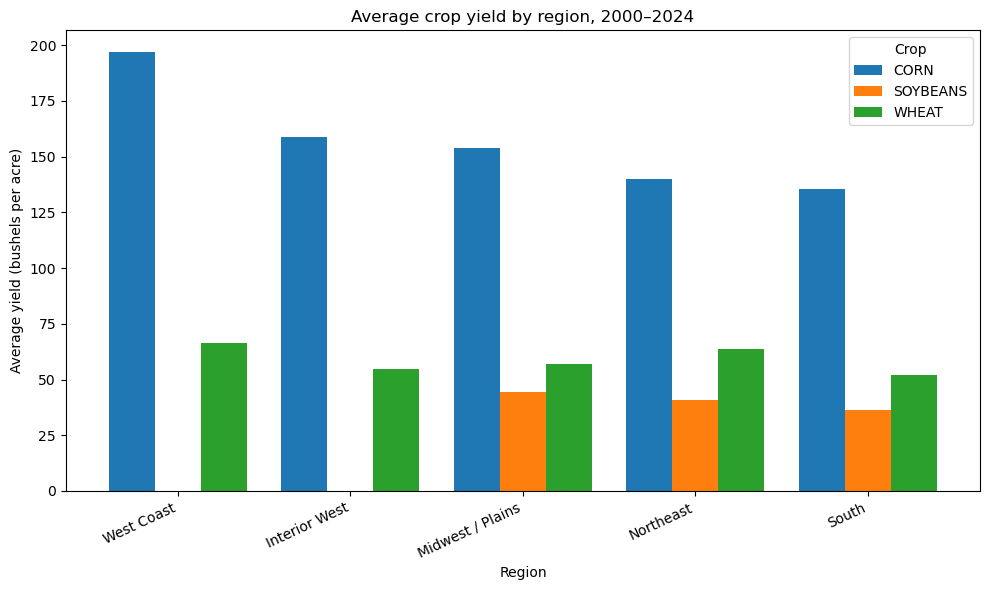

In [13]:
# Figure: Average crop yield by region and crop, 2000–2024

crop_region_avg = (
    crop_data
    .groupby(["region", "crop"], as_index=False)
    .agg(
        avg_yield_bu_per_acre=("yield_bu_per_acre", "mean"),
        n_records=("yield_bu_per_acre", "size")
    )
)

display(crop_region_avg)

# Pivot for grouped bar chart
yield_pivot = crop_region_avg.pivot(
    index="region",
    columns="crop",
    values="avg_yield_bu_per_acre"
)

# Sort regions by average yield across crops
yield_pivot = yield_pivot.loc[yield_pivot.mean(axis=1).sort_values(ascending=False).index]

ax = yield_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.xlabel("Region")
plt.ylabel("Average yield (bushels per acre)")
plt.title("Average crop yield by region, 2000–2024")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Crop")
plt.tight_layout()
plt.show()

Figure 1. Average crop yield by region and crop, 2000–2024

This chart gives a baseline view of agricultural outcomes across regions and crops. Corn has higher yield values than wheat and soybeans, while soybean records appear mainly in the Midwest / Plains, Northeast, and South in our merged dataset.

In [15]:
# Check which crops appear in each region
crop_presence = (
    crop_data
    .groupby(["region", "crop"])
    .size()
    .reset_index(name="n_records")
    .pivot(index="region", columns="crop", values="n_records")
    .fillna(0)
    .astype(int)
)

display(crop_presence)

crop,CORN,SOYBEANS,WHEAT
region,,,
Interior West,175,0,194
Midwest / Plains,300,1488,294
Northeast,125,620,124
South,350,1526,332
West Coast,75,0,75


In [16]:
# States with soybean records
soybean_states = (
    crop_data[crop_data["crop"] == "SOYBEANS"]
    [["region", "state"]]
    .drop_duplicates()
    .sort_values(["region", "state"])
)

display(soybean_states)

,region,state
2058,Midwest / Plains,ILLINOIS
2059,Midwest / Plains,INDIANA
2060,Midwest / Plains,IOWA
2061,Midwest / Plains,KANSAS
2065,Midwest / Plains,MICHIGAN
2066,Midwest / Plains,MINNESOTA
2068,Midwest / Plains,MISSOURI
2069,Midwest / Plains,NEBRASKA
2073,Midwest / Plains,NORTH DAKOTA
2074,Midwest / Plains,OHIO


Soybean records are concentrated in the Midwest / Plains, Northeast, and South in this dataset, while West Coast and Interior West do not have soybean yield records. Corn has the highest average yield across all regions, but the West Coast has fewer records, so its higher average should be interpreted carefully.

,region,avg_yield_bu_per_acre,n_records
4,West Coast,196.840000,75
0,Interior West,158.691429,175
1,Midwest / Plains,153.893333,300
2,Northeast,139.936000,125
3,South,135.474286,350


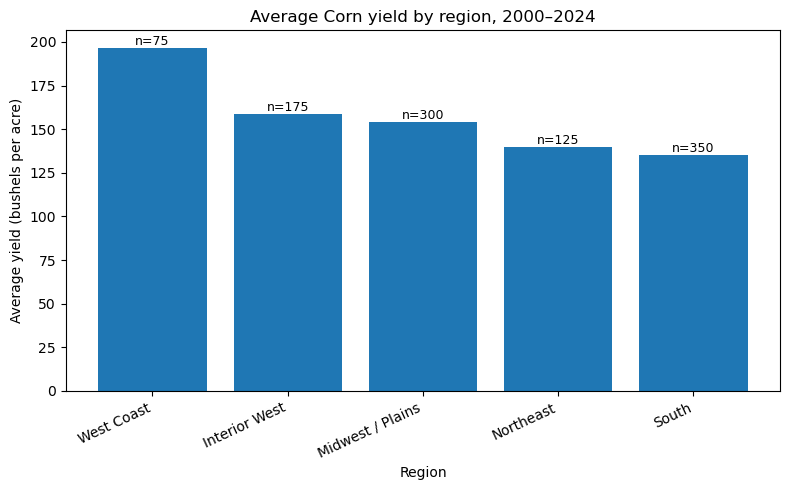

,region,avg_yield_bu_per_acre,n_records
0,Midwest / Plains,44.220094,1488
1,Northeast,40.816935,620
2,South,36.228047,1526


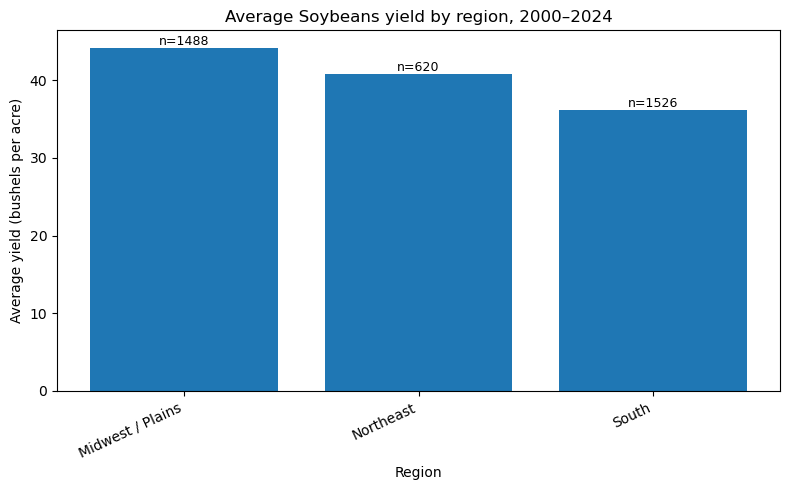

,region,avg_yield_bu_per_acre,n_records
4,West Coast,66.397333,75
2,Northeast,63.830645,124
1,Midwest / Plains,56.830612,294
0,Interior West,54.743814,194
3,South,52.159639,332


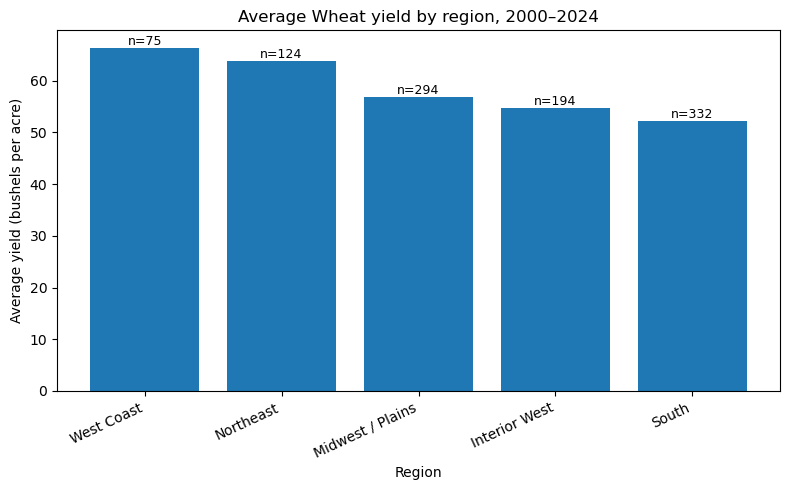

In [21]:
# Separate bar chart for each crop with sample size labels

for crop in sorted(crop_data["crop"].unique()):
    subset = (
        crop_data[crop_data["crop"] == crop]
        .groupby("region", as_index=False)
        .agg(
            avg_yield_bu_per_acre=("yield_bu_per_acre", "mean"),
            n_records=("yield_bu_per_acre", "size")
        )
        .sort_values("avg_yield_bu_per_acre", ascending=False)
    )

    display(subset)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        subset["region"],
        subset["avg_yield_bu_per_acre"]
    )

    for bar, n in zip(bars, subset["n_records"]):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.xlabel("Region")
    plt.ylabel("Average yield (bushels per acre)")
    plt.title(f"Average {crop.title()} yield by region, 2000–2024")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

In [22]:
# Merge valid precipitation back to crop-level data
crop_precip = crop_data.merge(
    precip_data[
        [
            "state",
            "year",
            "annual_precip_in",
            "growing_season_precip_in",
            "growing_season_precip_state_percentile"
        ]
    ],
    on=["state", "year"],
    how="inner",
    suffixes=("", "_valid")
)

print(crop_precip.shape)
print(crop_precip["state"].nunique())
print(crop_precip["crop"].value_counts())

(5167, 23)
37
crop
SOYBEANS    3367
CORN         900
WHEAT        900
Name: count, dtype: int64


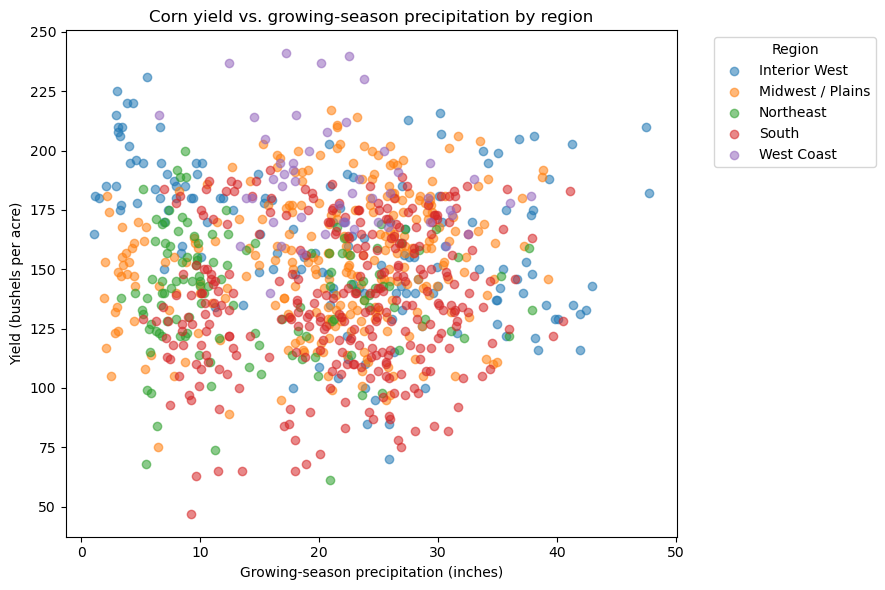

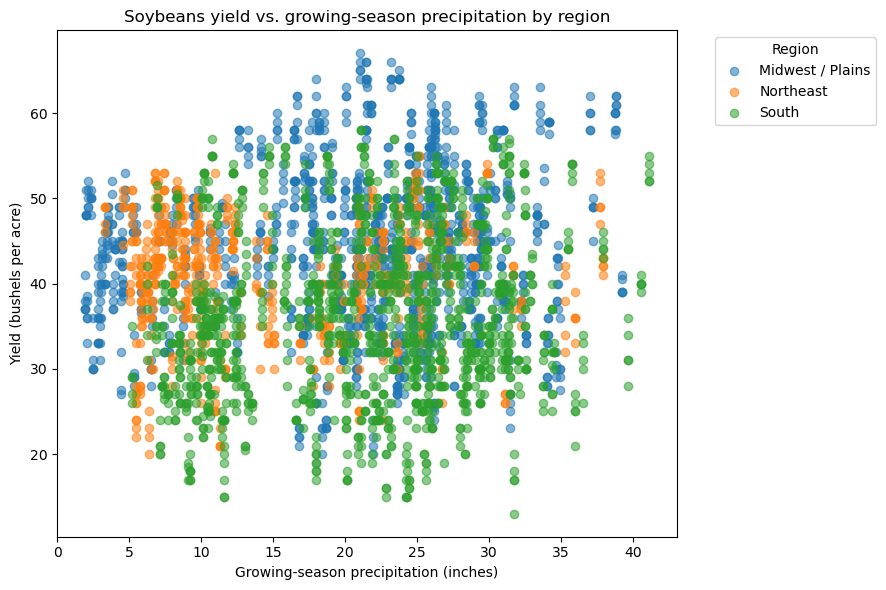

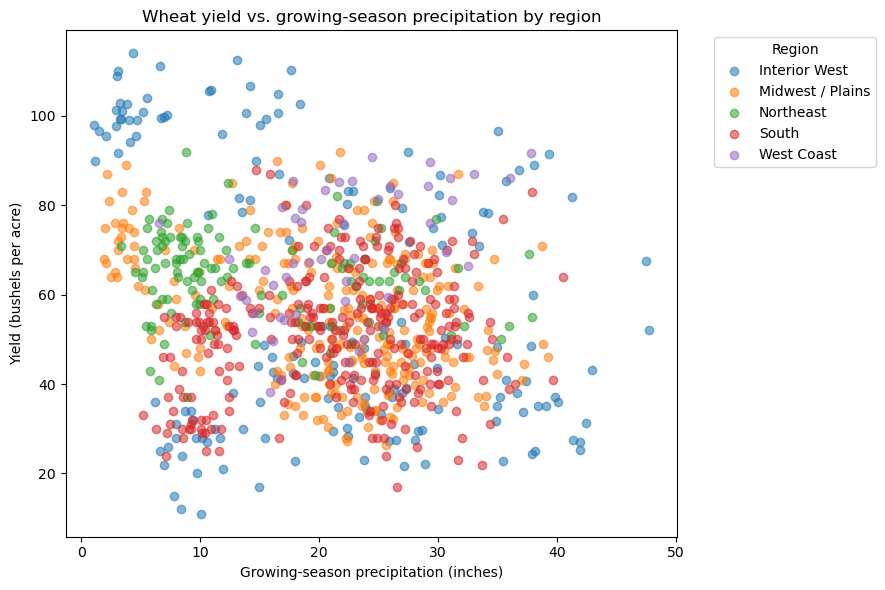

In [23]:
# Scatterplot: growing-season precipitation vs yield, separated by crop

for crop in sorted(crop_precip["crop"].unique()):
    subset_crop = crop_precip[crop_precip["crop"] == crop]

    plt.figure(figsize=(9, 6))

    for region, group in subset_crop.groupby("region"):
        plt.scatter(
            group["growing_season_precip_in"],
            group["yield_bu_per_acre"],
            alpha=0.55,
            label=region
        )

    plt.xlabel("Growing-season precipitation (inches)")
    plt.ylabel("Yield (bushels per acre)")
    plt.title(f"{crop.title()} yield vs. growing-season precipitation by region")
    plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [25]:
# Correlation by crop and region

corr_rows = []

for crop in sorted(crop_precip["crop"].unique()):
    for region in sorted(crop_precip["region"].unique()):
        subset = crop_precip[
            (crop_precip["crop"] == crop) &
            (crop_precip["region"] == region)
        ]

        if len(subset) >= 10:
            corr = subset["growing_season_precip_in"].corr(subset["yield_bu_per_acre"])
        else:
            corr = np.nan

        corr_rows.append({
            "crop": crop,
            "region": region,
            "n_records": len(subset),
            "corr_gs_precip_yield": corr
        })

corr_table = pd.DataFrame(corr_rows)

display(
    corr_table.sort_values(
        ["crop", "corr_gs_precip_yield"],
        ascending=[True, False]
    )
)

,crop,region,n_records,corr_gs_precip_yield
1,CORN,Midwest / Plains,275,0.163964
3,CORN,South,300,0.111056
2,CORN,Northeast,125,-0.047381
4,CORN,West Coast,50,-0.244667
0,CORN,Interior West,150,-0.406160
8,SOYBEANS,South,1383,0.137516
6,SOYBEANS,Midwest / Plains,1364,0.111529
7,SOYBEANS,Northeast,620,-0.020765
5,SOYBEANS,Interior West,0,NaN
9,SOYBEANS,West Coast,0,NaN


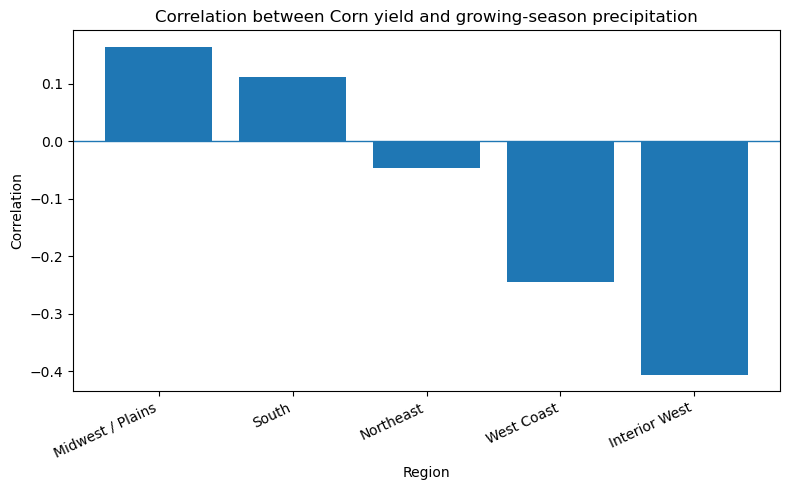

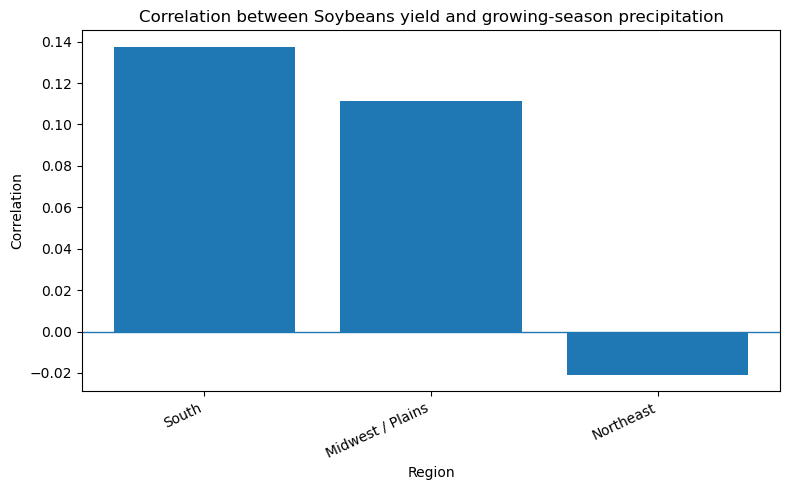

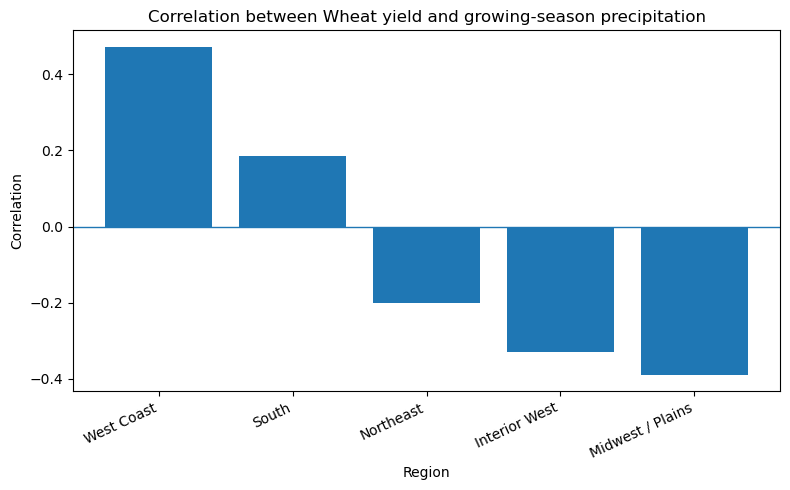

In [26]:
# Bar chart of correlation by crop and region

for crop in sorted(corr_table["crop"].unique()):
    subset = (
        corr_table[corr_table["crop"] == crop]
        .dropna(subset=["corr_gs_precip_yield"])
        .sort_values("corr_gs_precip_yield", ascending=False)
    )

    plt.figure(figsize=(8, 5))
    plt.bar(
        subset["region"],
        subset["corr_gs_precip_yield"]
    )

    plt.axhline(0, linewidth=1)
    plt.xlabel("Region")
    plt.ylabel("Correlation")
    plt.title(f"Correlation between {crop.title()} yield and growing-season precipitation")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

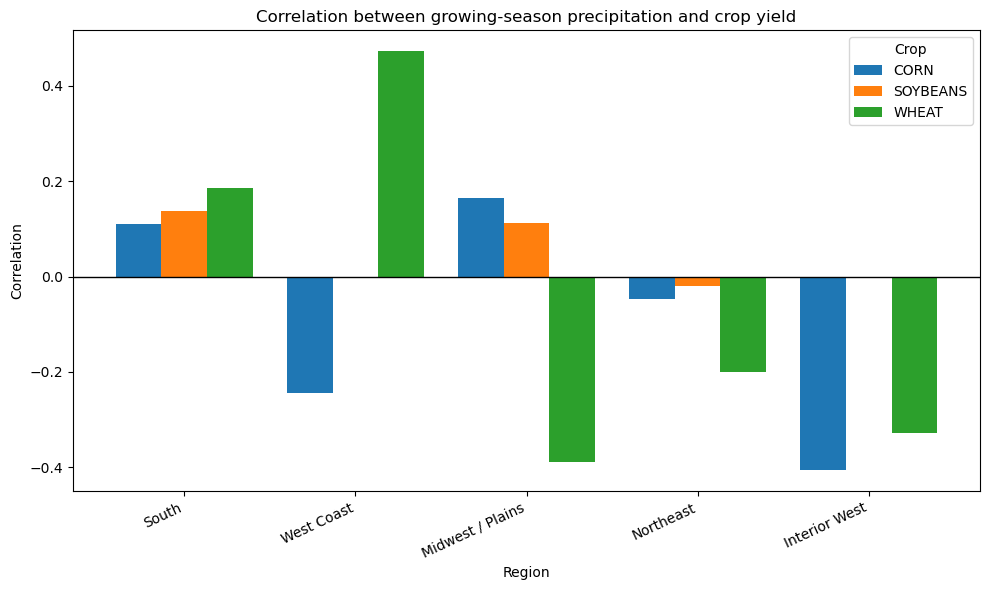

In [27]:
# Combine crop-region correlations into one grouped bar chart

corr_plot = corr_table.dropna(subset=["corr_gs_precip_yield"]).copy()

corr_pivot = corr_plot.pivot(
    index="region",
    columns="crop",
    values="corr_gs_precip_yield"
)

# Sort regions by average correlation
corr_pivot = corr_pivot.loc[
    corr_pivot.mean(axis=1).sort_values(ascending=False).index
]

ax = corr_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Region")
plt.ylabel("Correlation")
plt.title("Correlation between growing-season precipitation and crop yield")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Crop")
plt.tight_layout()
plt.show()

The relationship between growing-season precipitation and yield is not consistent across crops or regions. Some crop-region pairs show weak positive correlations, while others show negative correlations. This suggests that precipitation alone does not fully explain crop yield patterns, and motivates looking at damaging weather events and crop damage in addition to rainfall totals.

,region,total_crop_damage_usd,total_damage_events,n_state_years
3,South,3.261875e+10,10289.0,350
1,Midwest / Plains,1.941081e+10,16292.0,300
4,West Coast,5.550418e+09,497.0,75
0,Interior West,3.864976e+08,667.0,194
2,Northeast,1.719184e+08,1174.0,125


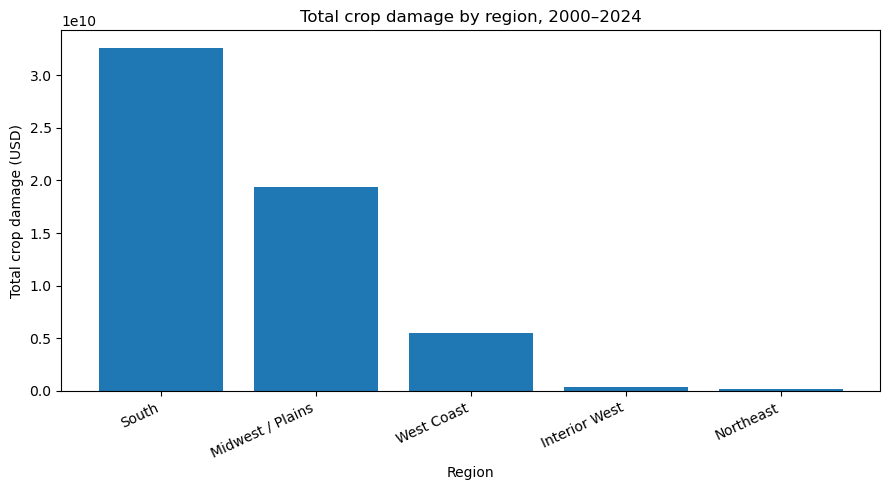

In [28]:
# Figure: Total crop damage by region, 2000–2024

region_damage_total = (
    damage_data
    .groupby("region", as_index=False)
    .agg(
        total_crop_damage_usd=("crop_damage_usd", "sum"),
        total_damage_events=("crop_damage_event_count", "sum"),
        n_state_years=("crop_damage_usd", "size")
    )
    .sort_values("total_crop_damage_usd", ascending=False)
)

display(region_damage_total)

plt.figure(figsize=(9, 5))

plt.bar(
    region_damage_total["region"],
    region_damage_total["total_crop_damage_usd"]
)

plt.xlabel("Region")
plt.ylabel("Total crop damage (USD)")
plt.title("Total crop damage by region, 2000–2024")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

,region,total_crop_damage_usd,total_damage_events,n_state_years,log_total_crop_damage_usd,avg_damage_per_state_year
3,South,3.261875e+10,10289.0,350,24.208153,9.319642e+07
4,West Coast,5.550418e+09,497.0,75,22.437139,7.400557e+07
1,Midwest / Plains,1.941081e+10,16292.0,300,23.689096,6.470269e+07
0,Interior West,3.864976e+08,667.0,194,19.772636,1.992256e+06
2,Northeast,1.719184e+08,1174.0,125,18.962530,1.375347e+06


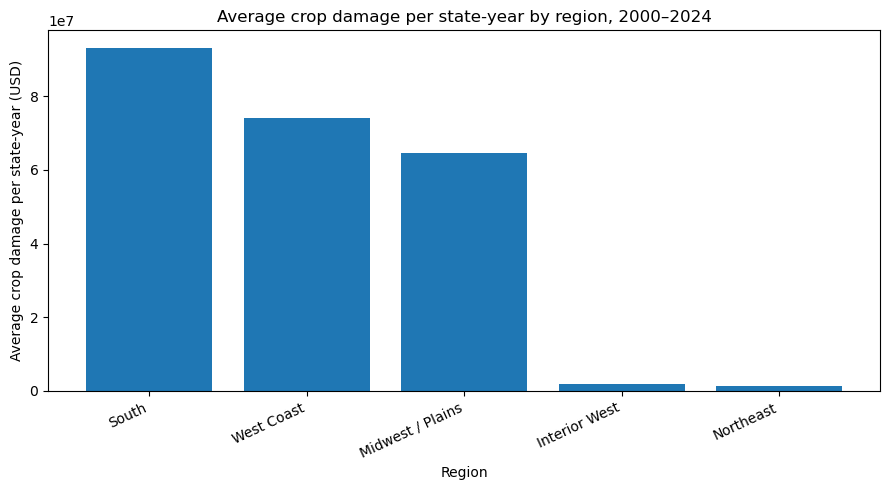

In [30]:
# Average crop damage per state-year by region

region_damage_total["avg_damage_per_state_year"] = (
    region_damage_total["total_crop_damage_usd"] /
    region_damage_total["n_state_years"]
)

region_damage_total = region_damage_total.sort_values(
    "avg_damage_per_state_year",
    ascending=False
)

display(region_damage_total)

plt.figure(figsize=(9, 5))

plt.bar(
    region_damage_total["region"],
    region_damage_total["avg_damage_per_state_year"]
)

plt.xlabel("Region")
plt.ylabel("Average crop damage per state-year (USD)")
plt.title("Average crop damage per state-year by region, 2000–2024")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

South has the highest average crop damage per state-year, followed by West Coast and Midwest / Plains. Interior West and Northeast have much lower average crop damage in this dataset.

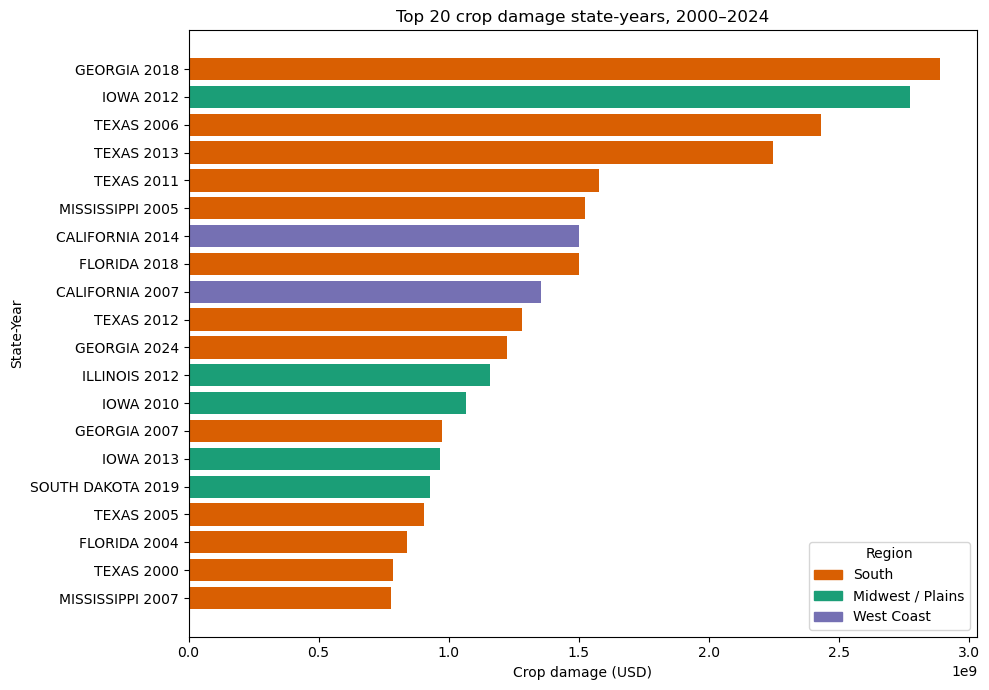

In [32]:
# Top 20 crop damage state-years, colored by region

top_damage = (
    damage_data
    .sort_values("crop_damage_usd", ascending=False)
    .head(20)
    .copy()
)

top_damage["state_year"] = (
    top_damage["state"] + " " + top_damage["year"].astype(str)
)

region_colors = {
    "South": "#d95f02",
    "Midwest / Plains": "#1b9e77",
    "West Coast": "#7570b3",
    "Interior West": "#e7298a",
    "Northeast": "#66a61e"
}

colors = top_damage["region"].map(region_colors)

plt.figure(figsize=(10, 7))

plt.barh(
    top_damage["state_year"],
    top_damage["crop_damage_usd"],
    color=colors
)

plt.xlabel("Crop damage (USD)")
plt.ylabel("State-Year")
plt.title("Top 20 crop damage state-years, 2000–2024")
plt.gca().invert_yaxis()

# Add legend manually
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color)
    for region, color in region_colors.items()
    if region in top_damage["region"].values
]

labels = [
    region
    for region in region_colors.keys()
    if region in top_damage["region"].values
]

plt.legend(handles, labels, title="Region", loc="lower right")

plt.tight_layout()
plt.show()

The largest crop damage records are concentrated in a small number of state-year cases. Many of the top damage years are in the South and Midwest / Plains, but California also appears among the highest-damage cases. This suggests that regional crop damage patterns may be driven by a few severe weather years rather than evenly distributed damage across all years.

,region,total_crop_damage_usd,damage_share_percent
3,South,3.261875e+10,56.105352
1,Midwest / Plains,1.941081e+10,33.387247
4,West Coast,5.550418e+09,9.546907
0,Interior West,3.864976e+08,0.664789
2,Northeast,1.719184e+08,0.295705


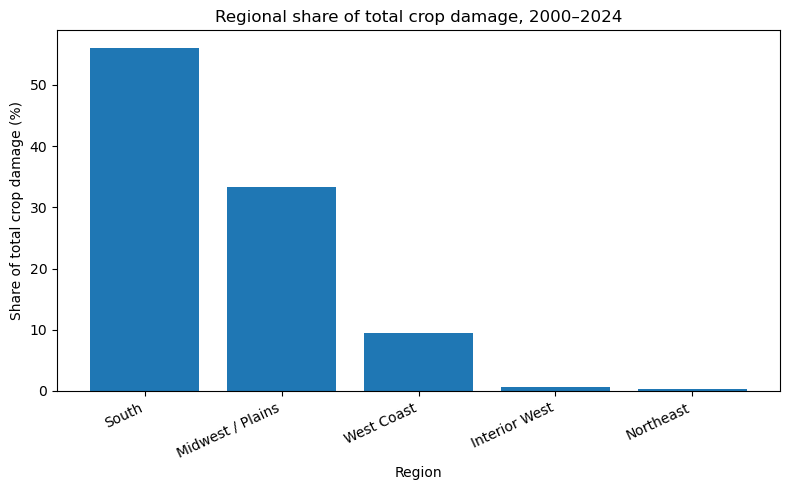

In [38]:
# Regional share of total crop damage as percent

region_share = (
    damage_data
    .groupby("region", as_index=False)
    .agg(total_crop_damage_usd=("crop_damage_usd", "sum"))
)

region_share["damage_share_percent"] = (
    region_share["total_crop_damage_usd"] /
    region_share["total_crop_damage_usd"].sum()
) * 100

region_share = region_share.sort_values("damage_share_percent", ascending=False)

display(region_share)

plt.figure(figsize=(8, 5))
plt.bar(region_share["region"], region_share["damage_share_percent"])

plt.xlabel("Region")
plt.ylabel("Share of total crop damage (%)")
plt.title("Regional share of total crop damage, 2000–2024")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

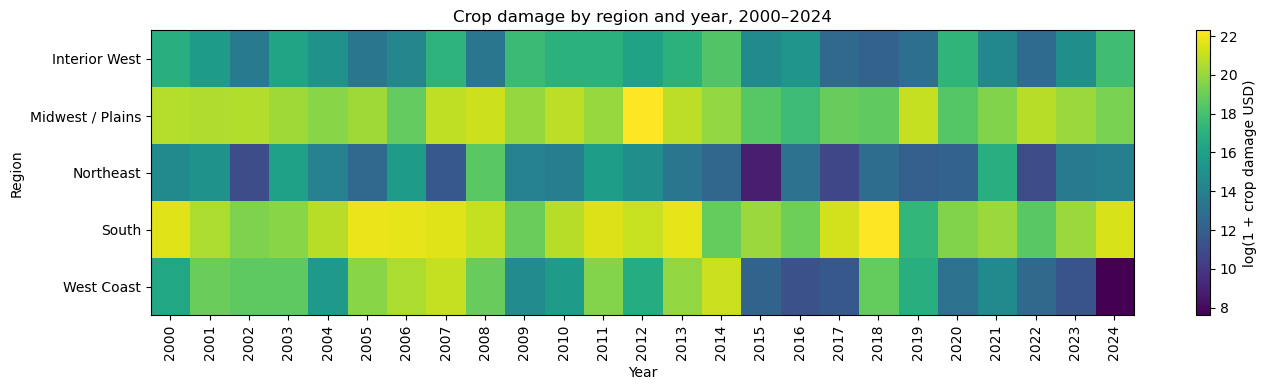

In [36]:
region_year_damage = (
    damage_data
    .groupby(["region", "year"], as_index=False)
    .agg(total_crop_damage_usd=("crop_damage_usd", "sum"))
)

heatmap_data = region_year_damage.pivot(
    index="region",
    columns="year",
    values="total_crop_damage_usd"
).fillna(0)

heatmap_log = np.log1p(heatmap_data)

plt.figure(figsize=(14, 4))
plt.imshow(heatmap_log, aspect="auto")

plt.yticks(range(len(heatmap_log.index)), heatmap_log.index)
plt.xticks(range(len(heatmap_log.columns)), heatmap_log.columns, rotation=90)

plt.colorbar(label="log(1 + crop damage USD)")
plt.xlabel("Year")
plt.ylabel("Region")
plt.title("Crop damage by region and year, 2000–2024")
plt.tight_layout()
plt.show()

The heatmap shows that crop damage varies strongly by both region and year, with several regional spikes rather than a smooth trend.